## Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [10]:
dataset = pd.read_csv('../Data/AirBnb_price.csv')

In [11]:
dataset.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [13]:
dataset.shape

(74111, 29)

## EDA

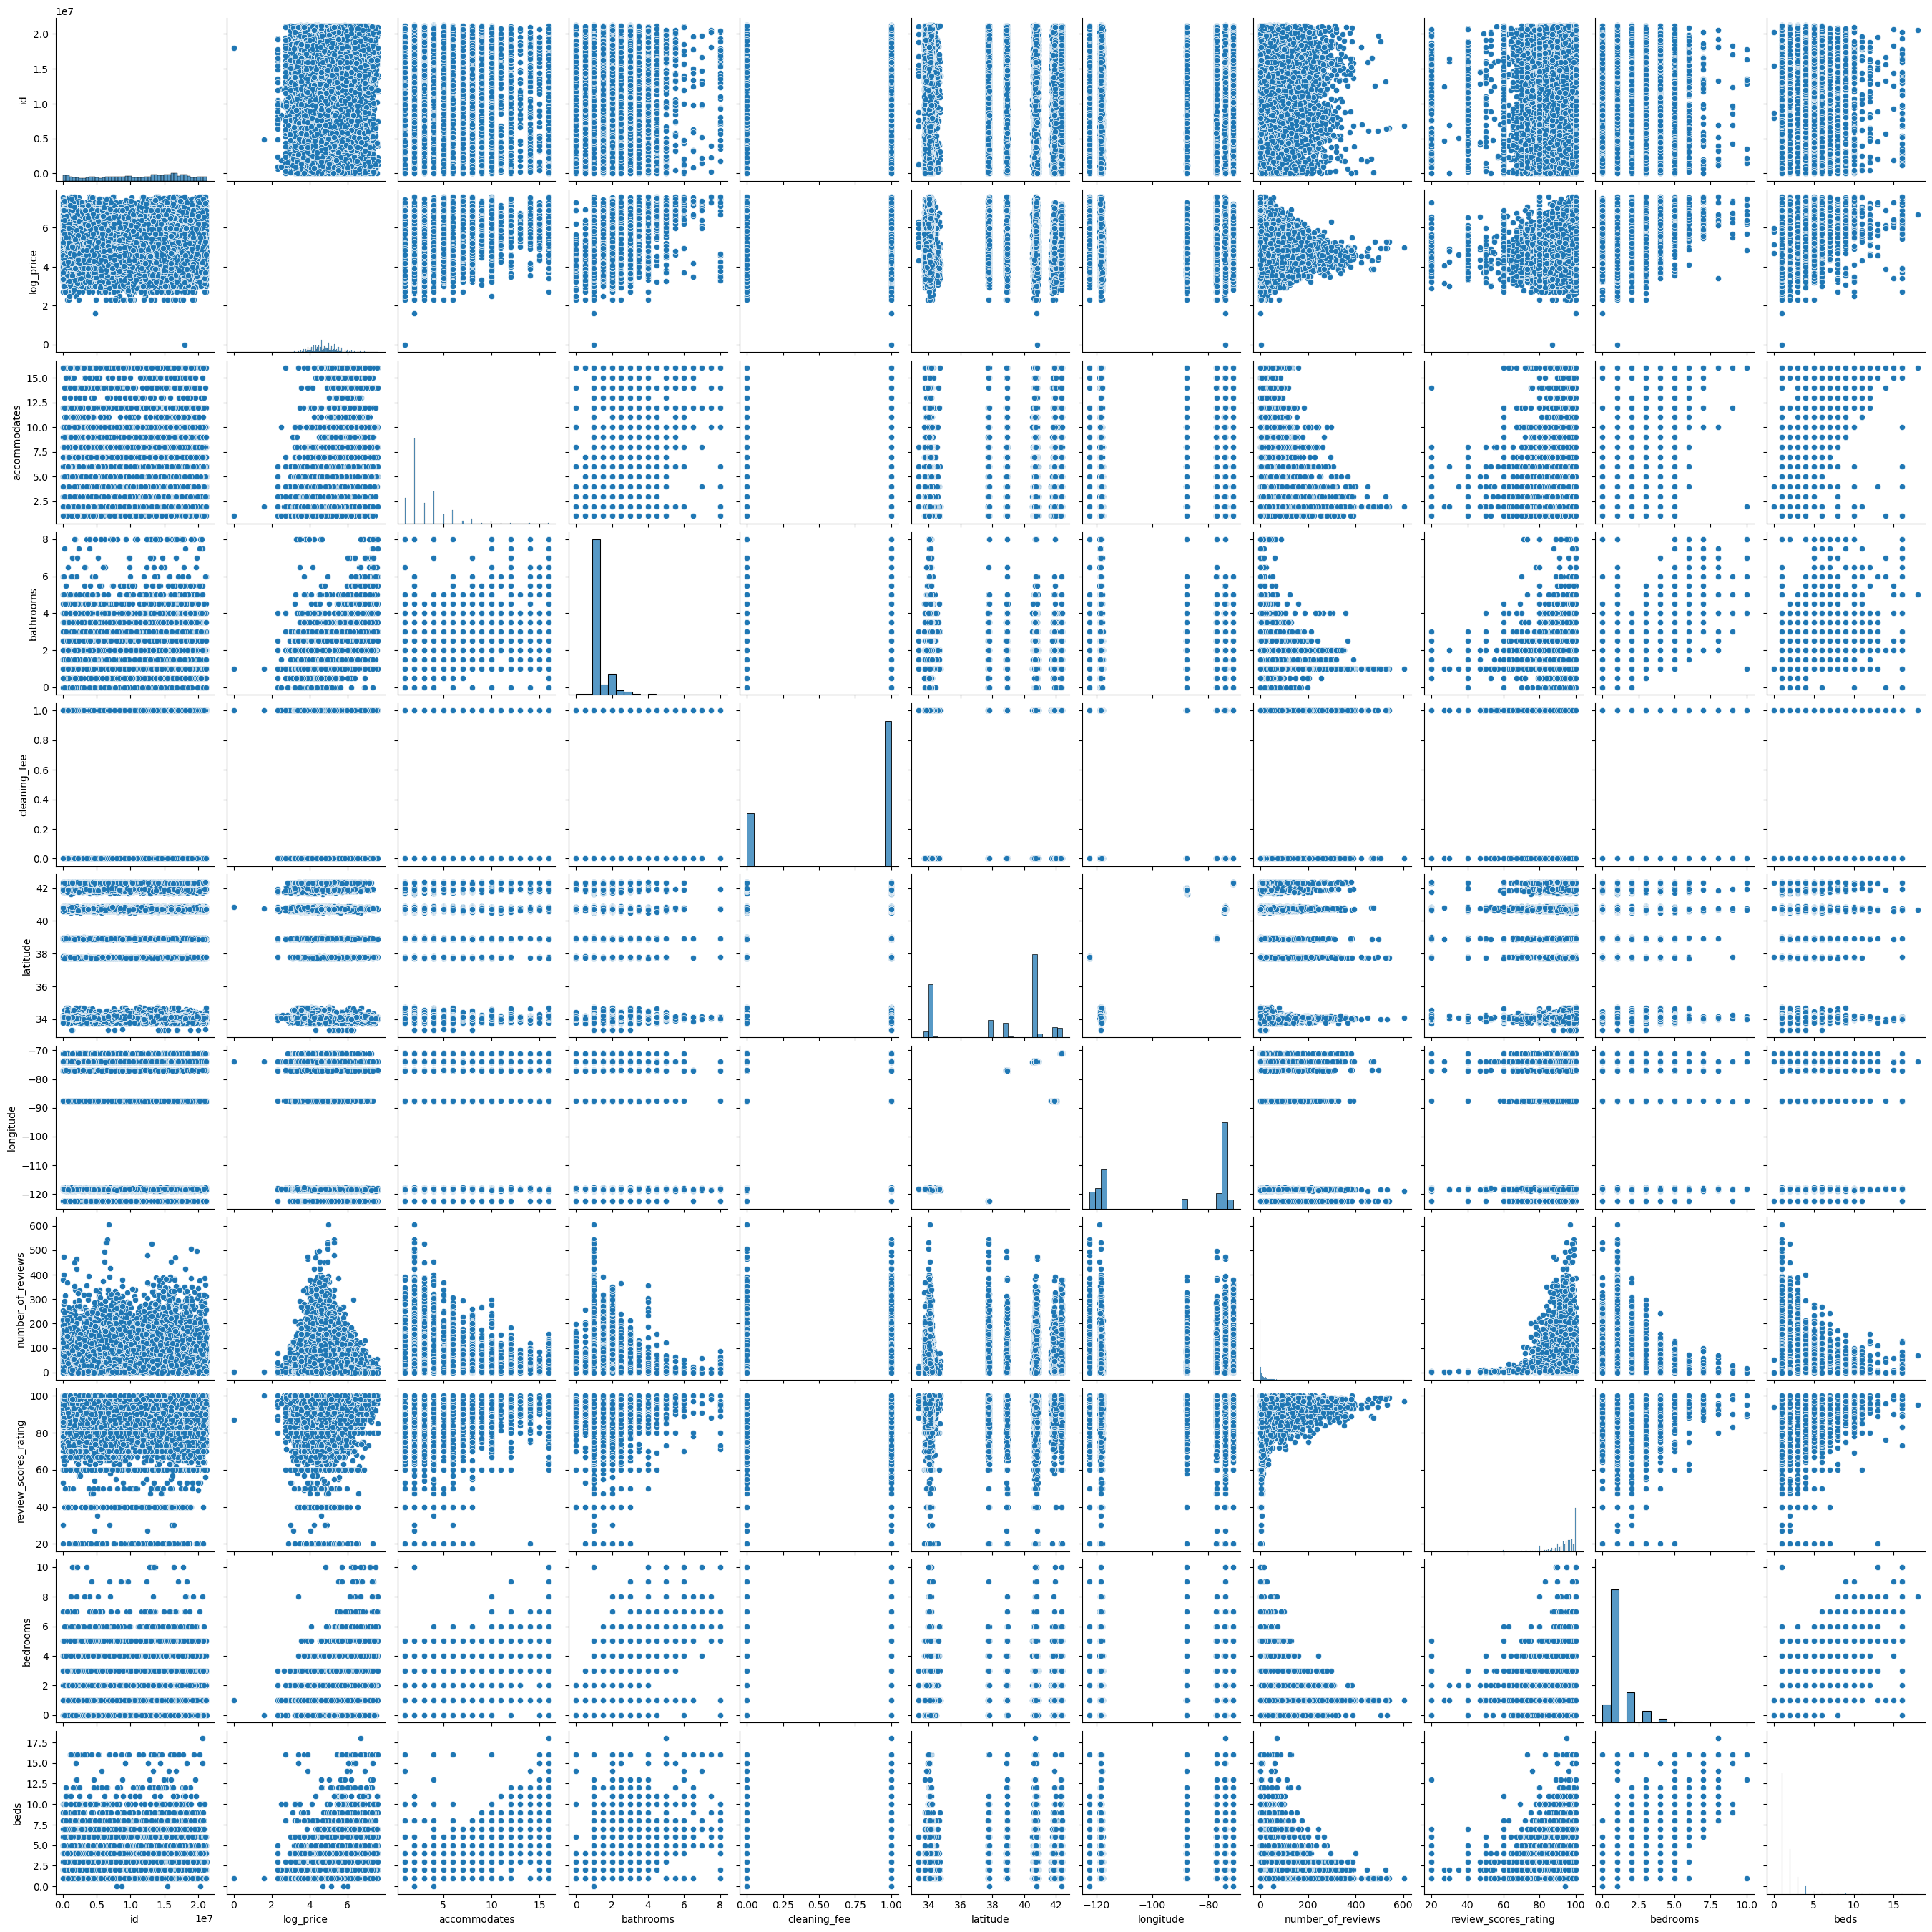

In [14]:
sns.pairplot(data=dataset)

In [15]:
dataset.drop(columns=['id','host_has_profile_pic','host_identity_verified','host_response_rate','last_review','latitude','longitude','neighbourhood','number_of_reviews','thumbnail_url','zipcode','beds','room_type','bathrooms','bed_type','cancellation_policy','description','first_review','host_since','name'],inplace=True)

In [16]:
dataset.dropna(inplace=True)

In [53]:
dataset.head()

,log_price,property_type,accommodates,cleaning_fee,city,instant_bookable,review_scores_rating,bedrooms,price
0,5.010635,Apartment,3,True,NYC,f,100.0,1.0,149.0
1,5.129899,Apartment,7,True,NYC,t,93.0,3.0,168.0
2,4.976734,Apartment,5,True,NYC,t,92.0,1.0,144.0
4,4.744932,Apartment,2,True,DC,t,40.0,0.0,114.0
5,4.442651,Apartment,2,True,SF,t,100.0,1.0,84.0


In [17]:
dataset.isnull().sum()

log_price               0
property_type           0
amenities               0
accommodates            0
cleaning_fee            0
city                    0
instant_bookable        0
review_scores_rating    0
bedrooms                0
dtype: int64

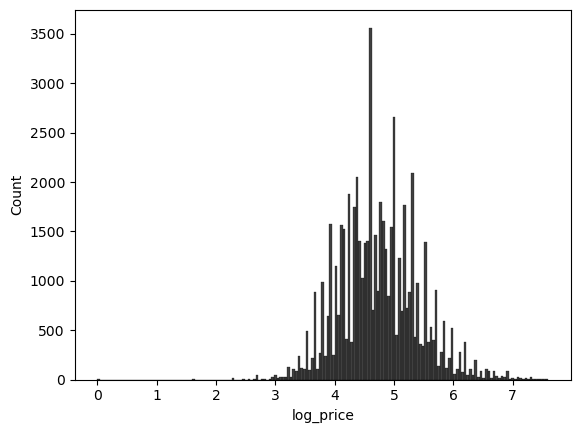

In [18]:
sns.histplot(x='log_price',data=dataset,color='black')
plt.show()

In [19]:
dataset['price']= dataset['log_price'].apply(lambda x:np.expm1(x))

In [20]:
dataset['price']

0        149.0
1        168.0
2        144.0
4        114.0
5         84.0
         ...  
74104     77.0
74105     69.0
74107    154.0
74108    184.0
74110    127.0
Name: price, Length: 57319, dtype: float64

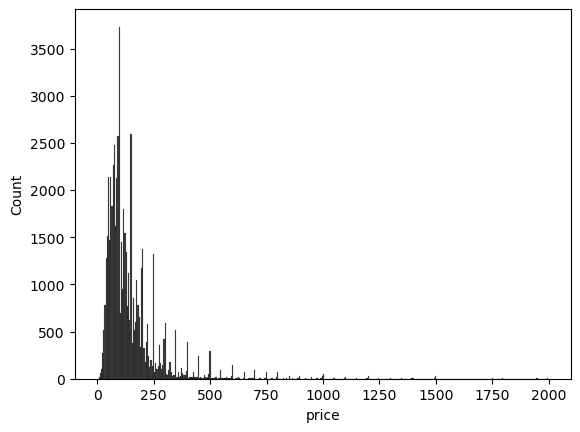

In [21]:
sns.histplot(x='price',data=dataset,color='black')
plt.show()

In [22]:
dataset['amenities'][0]

'{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly",Essentials,"Hair dryer",Iron,"translation missing: en.hosting_amenity_50"}'

In [23]:
dataset['amenities'][5]

'{TV,"Wireless Internet",Heating,"Smoke detector","Carbon monoxide detector","First aid kit","Fire extinguisher",Essentials,Hangers,"Laptop friendly workspace"}'

In [24]:
dataset['city'].unique()

array(['NYC', 'DC', 'SF', 'LA', 'Chicago', 'Boston'], dtype=object)

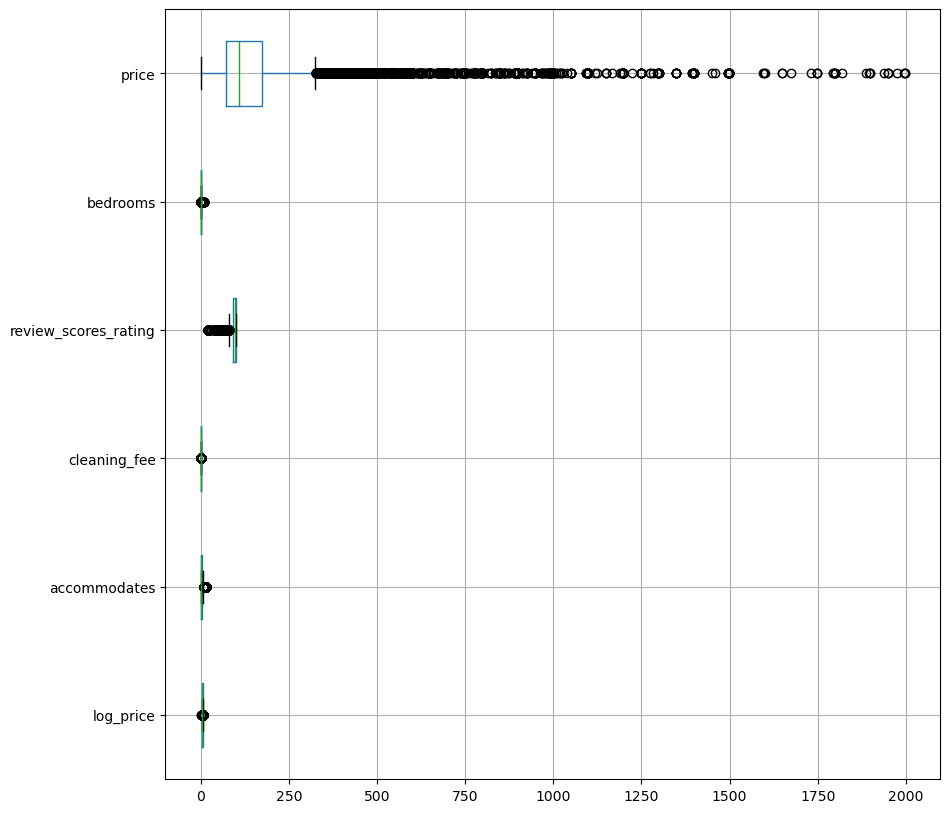

In [25]:
dataset.boxplot(figsize=(10,10),vert=False)
plt.show()

In [26]:
dataset.drop(columns=['amenities'],inplace=True)

In [44]:
dataset.select_dtypes('number').corr()['log_price'].sort_values(ascending=False)

log_price               1.000000
price                   0.852700
accommodates            0.587368
bedrooms                0.489896
review_scores_rating    0.091215
Name: log_price, dtype: float64

## train-test split

In [27]:
x = dataset.drop(columns=['log_price','price'])
y = dataset['log_price']

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Pipeline

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [30]:
numeric_features = x.select_dtypes('number').columns
categorical_features = x.select_dtypes('object').columns

In [31]:
numeric_pipeline = Pipeline([
    ("Scaling",StandardScaler())
])
categorical_pipeline = Pipeline([
    ("Encoding",OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
preprocessor = ColumnTransformer([
    ("Numeric",numeric_pipeline,numeric_features),
    ("Categorical",categorical_pipeline,categorical_features)
])

In [33]:
preprocessor

ColumnTransformer(transformers=[('Numeric',
                                 Pipeline(steps=[('Scaling',
                                                  StandardScaler())]),
                                 Index(['accommodates', 'review_scores_rating', 'bedrooms'], dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('Encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['property_type', 'city', 'instant_bookable'], dtype='object'))])

## Baseline Model selection

In [34]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score
dummy = DummyRegressor()
dummy.fit(x_train,y_train)
y_pred_dummy = dummy.predict(x_test)
print(r2_score(y_test,y_pred_dummy))

-0.0003930452176121868


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [36]:
models = {
    'Linear Regression':Pipeline([
        ('Preprocessor',preprocessor),
        ('Model',LinearRegression())
    ]),

    'Decision Tree':Pipeline([
        ('Preprocessor',preprocessor),
        ('Model',DecisionTreeRegressor(max_depth=4,random_state=42))
    ]),

    'Random Forest':Pipeline([
        ('Preprocessor',preprocessor),
        ('Model',RandomForestRegressor(n_estimators=100))
    ]),

}

In [34]:
dataset.head(1)

,log_price,property_type,accommodates,cleaning_fee,city,instant_bookable,review_scores_rating,bedrooms,price
0,5.010635,Apartment,3,True,NYC,f,100.0,1.0,149.0


In [35]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [36]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error,r2_score

In [37]:
cat_features=['property_type','cleaning_fee','city','instant_bookable']
cbr = CatBoostRegressor(cat_features=cat_features)
cbr.fit(x_train,y_train)
y_pred_cbr = cbr.predict(x_test)
print(r2_score(y_test,y_pred_cbr))

Learning rate set to 0.056343
0:	learn: 0.6555211	total: 113ms	remaining: 1m 52s
1:	learn: 0.6417142	total: 145ms	remaining: 1m 12s
2:	learn: 0.6283282	total: 180ms	remaining: 59.9s
3:	learn: 0.6164384	total: 220ms	remaining: 54.8s
4:	learn: 0.6064413	total: 273ms	remaining: 54.4s
5:	learn: 0.5965347	total: 316ms	remaining: 52.3s
6:	learn: 0.5870470	total: 337ms	remaining: 47.8s
7:	learn: 0.5786979	total: 373ms	remaining: 46.3s
8:	learn: 0.5713136	total: 414ms	remaining: 45.5s
9:	learn: 0.5643355	total: 449ms	remaining: 44.4s
10:	learn: 0.5580280	total: 473ms	remaining: 42.5s
11:	learn: 0.5519725	total: 488ms	remaining: 40.2s
12:	learn: 0.5462090	total: 503ms	remaining: 38.2s
13:	learn: 0.5409998	total: 514ms	remaining: 36.2s
14:	learn: 0.5362393	total: 524ms	remaining: 34.4s
15:	learn: 0.5321223	total: 533ms	remaining: 32.8s
16:	learn: 0.5281999	total: 547ms	remaining: 31.6s
17:	learn: 0.5245397	total: 559ms	remaining: 30.5s
18:	learn: 0.5214156	total: 570ms	remaining: 29.4s
19:	learn

In [38]:
print(mean_absolute_error(y_test,y_pred_cbr))
print(r2_score(y_test,y_pred_cbr))

0.35077307426584114
0.5258860569465551


In [40]:
print("training score",cbr.score(x_train,y_train))
print("testing score",cbr.score(x_test,y_test))

training score 0.5789178978049934
testing score 0.5258860569465551


## Cross-validation

In [37]:
from sklearn.model_selection import KFold ,cross_validate

In [38]:
cv= KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
for name,pipeline in models.items():
  scores= cross_validate(
      pipeline,x_train,y_train,
      cv=cv,
      n_jobs=-1,
      scoring={
          'MAE': 'neg_mean_absolute_error',
          'MSE': 'neg_mean_squared_error',
          'RMSE': 'neg_root_mean_squared_error',
          'R2': 'r2'
      }
  )
  mae = -scores['test_MAE'].mean()
  mse = -scores['test_MSE'].mean()
  rmse = -scores['test_RMSE'].mean()
  r2 = scores['test_R2'].mean()
  print(
      name,
      'MAE:', round(mae, 2),
      'MSE:', round(mse,2),
      'RMSE:', round(rmse, 2),
      'R2:',  round(r2, 2))

Linear Regression MAE: 0.39 MSE: 0.25 RMSE: 0.5 R2: 0.43
Decision Tree MAE: 0.39 MSE: 0.24 RMSE: 0.49 R2: 0.45
Random Forest MAE: 0.37 MSE: 0.23 RMSE: 0.48 R2: 0.49


## Hyperparamter tunning

In [40]:
from sklearn.model_selection import RandomizedSearchCV

### Random forest

In [41]:
rf_params = {
    "Model__n_estimators": [100, 200, 300, 500],
    "Model__max_depth": [None, 5, 10, 15, 20, 30],
    "Model__min_samples_split": [2, 5, 10],
    "Model__min_samples_leaf": [1, 2, 4],
    "Model__max_features": ["sqrt", "log2", None]
}

In [46]:
rf_search = RandomizedSearchCV(
    models['Random Forest'],
    param_distributions=rf_params,
   n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
rf_search.fit(x_train,y_train)
print("Random Forest best params:", rf_search.best_params_)
print("Random Forest best score:", rf_search.best_score_)

In [48]:
model1 = rf_search.best_estimator_
model1.fit(x_train,y_train)
y_pred_model1 = model1.predict(x_test)
print(f"Random Forest Tuned Model R2: {r2_score(y_test,y_pred_model1),:.2f}")

In [58]:
print("training score",model1.score(x_train,y_train))
print("testing score",model1.score(x_test,y_test))

training score 0.5831468190258626
testing score 0.5094979249434077


### Decision Tree

In [47]:
dt_params = {
    "Model__max_depth": [None, 5, 10, 15, 20, 30],
    "Model__min_samples_split": [2, 5, 10, 20],
    "Model__min_samples_leaf": [1, 2, 4, 8],
    "Model__max_features": [None, "sqrt", "log2"],
    "Model__criterion": ["squared_error", "friedman_mse", "absolute_error"]
}

In [48]:
dt_search = RandomizedSearchCV(
    models['Decision Tree'],
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
dt_search.fit(x_train,y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

{'Model__n_estimators': 300, 'Model__min_samples_split': 10, 'Model__min_samples_leaf': 2, 'Model__max_features': 'log2', 'Model__max_depth': 30}
-0.22627980421791555


In [49]:
model2 = dt_search.best_estimator_
model2.fit(x_train,y_train)
y_pred_model2 = model2.predict(x_test)
print(r2_score(y_test,y_pred_model1))

0.47684031379776237


In [59]:
print("training score",model2.score(x_train,y_train))
print("testing score",model2.score(x_test,y_test))

training score 0.47458852702822885
testing score 0.47684031379776237


## Save model

In [49]:
import joblib

In [50]:
joblib.dump(preprocessor,'Preprocessing.pkl')

['Preprocessing.pkl']

In [52]:
joblib.dump(model1,'AirBnb_price_predictor.pkl')